# Email Spam Classification Workflow
This notebook is organized block by block from data loading to final prediction.

## Steps
1. Load and inspect dataset
2. EDA and visualizations
3. Preprocessing
4. spaCy tokenization + lemmatization
5. Train-test split
6. TF-IDF feature engineering
7. Model selection
8. Hyperparameter tuning
9. Final evaluation
10. Prediction on new messages

In [1]:
# Block 1: Import required libraries
import re
import string
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import nltk
import spacy

from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
 )
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Block 2: Setup and initialize resources
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# Download required NLTK resources
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# Initialize spaCy tokenizer
nlp = spacy.blank("en")

In [3]:
# Block 3: Load and inspect dataset
from pathlib import Path

# Resolve dataset path for both workspace root and notebooks working dir
candidate_paths = [
    Path("dataset/combined_data.csv"),
    Path("../dataset/combined_data.csv"),
]

dataset_path = next((p for p in candidate_paths if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("combined_data.csv not found in expected dataset paths")

df = pd.read_csv(dataset_path)

print("Using dataset:", dataset_path.resolve())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Using dataset: C:\projects\spam-classification\dataset\combined_data.csv
Shape: (83448, 2)
Columns: ['label', 'text']


,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [4]:
# Block 4: Basic EDA checks
print("Missing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["label"].value_counts())

# Ensure text column is string
df["text"] = df["text"].astype(str)

# Create text length features
df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].str.split().apply(len)

Missing values:
label    0
text     0
dtype: int64

Class distribution:
label
1    43910
0    39538
Name: count, dtype: int64


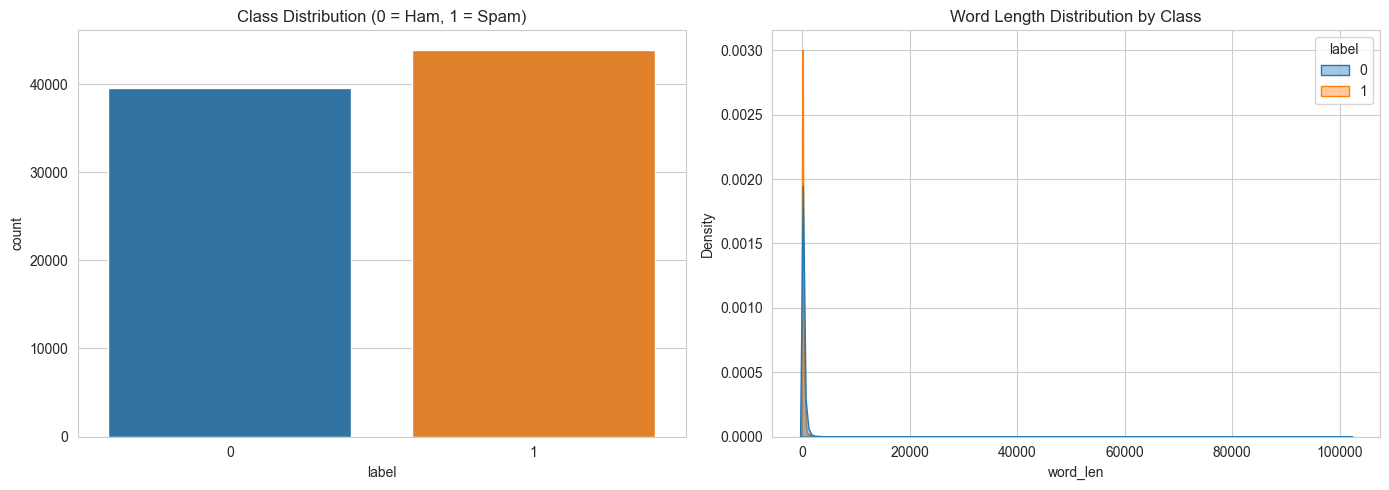

In [5]:
# Block 5: EDA visualization - class distribution and word length
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x="label", data=df, ax=axes[0])
axes[0].set_title("Class Distribution (0 = Ham, 1 = Spam)")

sns.kdeplot(
    data=df,
    x="word_len",
    hue="label",
    fill=True,
    common_norm=False,
    alpha=0.4,
    ax=axes[1],
)
axes[1].set_title("Word Length Distribution by Class")

plt.tight_layout()
plt.show()

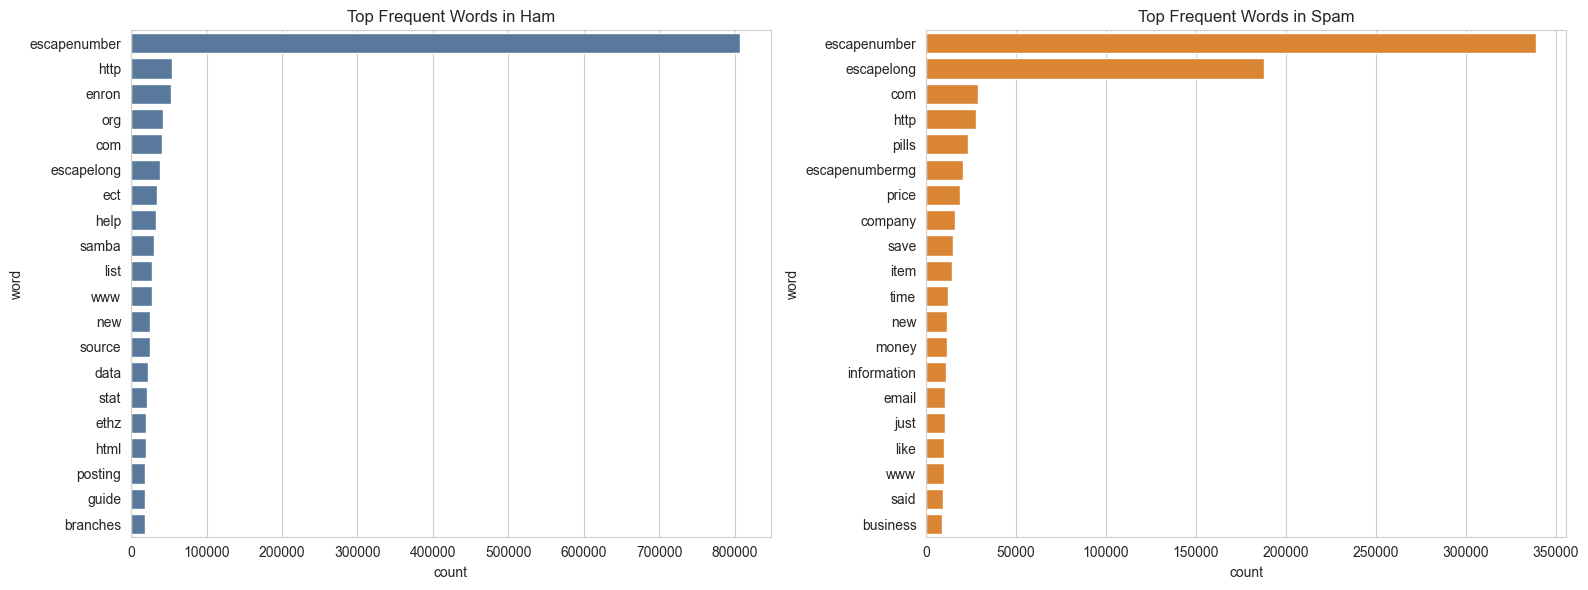

In [6]:
# Block 6: Frequent words in ham and spam
def top_words(text_series, n=20):
    joined = " ".join(text_series.tolist())
    tokens = re.findall(r"[a-zA-Z']+", joined.lower())
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS and len(t) > 2]
    return Counter(tokens).most_common(n)

ham_top = top_words(df.loc[df["label"] == 0, "text"], n=20)
spam_top = top_words(df.loc[df["label"] == 1, "text"], n=20)

ham_df = pd.DataFrame(ham_top, columns=["word", "count"])
spam_df = pd.DataFrame(spam_top, columns=["word", "count"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=ham_df, x="count", y="word", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top Frequent Words in Ham")

sns.barplot(data=spam_df, x="count", y="word", ax=axes[1], color="#F58518")
axes[1].set_title("Top Frequent Words in Spam")

plt.tight_layout()
plt.show()

In [7]:
# Block 7: Preprocessing (cleanup only)
lemmatizer = WordNetLemmatizer()
stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(r"\d+", " ", text)  # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [8]:
# Block 8: spaCy tokenization + stopword removal + lemmatization
def tokenize_with_spacy(text: str) -> str:
    tokens = [tok.text for tok in nlp(text) if not tok.is_space]
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

df["preprocessed_text"] = df["text"].apply(clean_text)
df["tokenized_text"] = df["preprocessed_text"].apply(tokenize_with_spacy)

print("Sample transformed text:")
df[["text", "preprocessed_text", "tokenized_text"]].head(3)

Sample transformed text:


,text,preprocessed_text,tokenized_text
0,ounce feather bowl hummingbird opec moment ala...,ounce feather bowl hummingbird opec moment ala...,ounce feather bowl hummingbird opec moment ala...
1,wulvob get your medircations online qnb ikud v...,wulvob get your medircations online qnb ikud v...,wulvob medircations online qnb ikud viagra esc...
2,computer connection from cnn com wednesday es...,computer connection from cnn com wednesday esc...,computer connection cnn com wednesday escapenu...


In [9]:
# Block 9: Train-test split
X = df["tokenized_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 66758
Test size: 16690


In [10]:
# Block 10: TF-IDF feature engineering + model selection
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

models = {
    "naive_bayes": MultinomialNB(),
    "logistic_regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "random_forest": RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1),
}

results = []
for model_name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)

    results.append(
        {
            "embedding": "tfidf",
            "model": model_name,
            "accuracy": acc,
            "f1": f1,
            "precision": prec,
            "recall": rec,
        }
    )

results_df = pd.DataFrame(results).sort_values(by=["f1", "accuracy"], ascending=False)
print("Model comparison:")
results_df

Model comparison:


,embedding,model,accuracy,f1,precision,recall
2,tfidf,random_forest,0.986878,0.987559,0.985376,0.989752
1,tfidf,logistic_regression,0.985141,0.985944,0.981494,0.990435
0,tfidf,naive_bayes,0.974655,0.975671,0.985706,0.965839


In [11]:
# Block 11: Hyperparameter tuning (best baseline model)
best_row = results_df.iloc[0]
best_model_name = best_row["model"]

print(f"Best baseline: {best_model_name} + tfidf")

X_train_best = tfidf.fit_transform(X_train)
X_test_best = tfidf.transform(X_test)

if best_model_name == "naive_bayes":
    param_grid = {"alpha": [0.1, 0.3, 0.5, 1.0]}
    estimator = MultinomialNB()
elif best_model_name == "logistic_regression":
    param_grid = {"C": [0.1, 0.5, 1.0, 2.0], "solver": ["liblinear", "lbfgs"]}
    estimator = LogisticRegression(max_iter=3000, n_jobs=-1)
else:
    param_grid = {
        "n_estimators": [200, 300],
        "max_depth": [None, 20],
        "min_samples_split": [2, 5],
    }
    estimator = RandomForestClassifier(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1,
 )

grid.fit(X_train_best, y_train)
best_model = grid.best_estimator_

print("Best params:", grid.best_params_)

Best baseline: random_forest + tfidf
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


Final Metrics
Accuracy: 0.9862
Precision: 0.9849
Recall: 0.989
F1: 0.9869

Classification Report:

              precision    recall  f1-score   support

           0     0.9877    0.9832    0.9854      7908
           1     0.9849    0.9890    0.9869      8782

    accuracy                         0.9862     16690
   macro avg     0.9863    0.9861    0.9862     16690
weighted avg     0.9862    0.9862    0.9862     16690



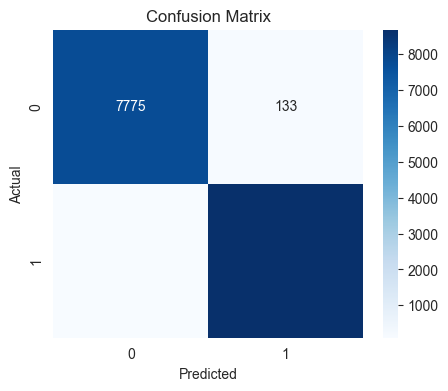

In [12]:
# Block 12: Final evaluation
final_preds = best_model.predict(X_test_best)

print("Final Metrics")
print("Accuracy:", round(accuracy_score(y_test, final_preds), 4))
print("Precision:", round(precision_score(y_test, final_preds), 4))
print("Recall:", round(recall_score(y_test, final_preds), 4))
print("F1:", round(f1_score(y_test, final_preds), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, final_preds, digits=4))

cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
# Block 13: Prediction on new messages
def predict_message(message: str) -> str:
    preprocessed = clean_text(message)
    tokenized = tokenize_with_spacy(preprocessed)
    vectorized = tfidf.transform([tokenized])
    pred = best_model.predict(vectorized)[0]
    return "Spam" if pred == 1 else "Ham"

sample_messages = [
    "Congratulations! You have won a free iPhone. Click here to claim now.",
    "Can we reschedule our meeting to tomorrow afternoon?",
    "Limited offer: Buy medicine online at 70% discount.",
]

print("Sample predictions:")
for msg in sample_messages:
    label = predict_message(msg)
    print(f"Text: {msg}\nPrediction: {label}\n")

Sample predictions:
Text: Congratulations! You have won a free iPhone. Click here to claim now.
Prediction: Ham

Text: Can we reschedule our meeting to tomorrow afternoon?
Prediction: Ham

Text: Limited offer: Buy medicine online at 70% discount.
Prediction: Spam

